In [1]:
import seaborn as sns

In [2]:
import pandas as pd

In [3]:
from lib.common import *
from lib.boat import boat

In [4]:
sails = ['Nr.1', 'Nr.2', 'Nr.3', 'Stormjib', 'Mainsail', 'Genaker', 'Mizzen', 'Mizzen staysail']

In [5]:
df_base=boat('Petsamo').get_sail_data()
df_base

,tws,spd,twd,twa,sails,heel
2023-01-06 22:49:18.300585032,24.0,8.0,134,158,"[Mainsail, Mizzen, Mizzen staysail, Nr.2]",NaN
2023-01-07 05:07:22.956870556,25.0,8.0,137,164,"[Mainsail, Mizzen, Nr.3]",NaN
2023-01-07 12:44:23.910266638,21.0,8.0,130,169,"[Mainsail, Mizzen, Mizzen staysail, Nr.1, Nr.3]",NaN
2023-01-07 14:56:50.259599923,20.0,8.0,126,141,"[Mainsail, Mizzen, Mizzen staysail, Nr.2, Nr.3]",NaN
2023-01-07 14:58:51.486292124,21.0,7.0,129,142,"[Mainsail, Mizzen, Mizzen staysail, Nr.2, Nr.3]",NaN
...,...,...,...,...,...,...
2023-01-20 00:54:49.990070105,19.4,5.7,296,45,"[Mainsail, Nr.2]",32.0
2023-01-20 02:51:41.800625563,19.0,5.7,294,-45,"[Mainsail, Nr.2]",-31.0
2023-01-20 13:57:32.897197723,22.8,5.8,293,45,"[Mainsail, Mizzen, Nr.3]",35.0
2023-01-20 16:41:16.019813299,20.5,5.7,288,45,[Mainsail],36.0


In [36]:
df['spd'].max()

8.0

In [6]:
df = df_base.copy()
df = df.reset_index(drop=True)
df

,tws,spd,twd,twa,sails,heel
0,24.0,8.0,134,158,"[Mainsail, Mizzen, Mizzen staysail, Nr.2]",NaN
1,25.0,8.0,137,164,"[Mainsail, Mizzen, Nr.3]",NaN
2,21.0,8.0,130,169,"[Mainsail, Mizzen, Mizzen staysail, Nr.1, Nr.3]",NaN
3,20.0,8.0,126,141,"[Mainsail, Mizzen, Mizzen staysail, Nr.2, Nr.3]",NaN
4,21.0,7.0,129,142,"[Mainsail, Mizzen, Mizzen staysail, Nr.2, Nr.3]",NaN
...,...,...,...,...,...,...
96,19.4,5.7,296,45,"[Mainsail, Nr.2]",32.0
97,19.0,5.7,294,-45,"[Mainsail, Nr.2]",-31.0
98,22.8,5.8,293,45,"[Mainsail, Mizzen, Nr.3]",35.0
99,20.5,5.7,288,45,[Mainsail],36.0


In [7]:
dict_df_by_sail = {}
for sail in sails:
    dict_df_by_sail.update( {sail: df.iloc[[idx for idx in df.index if sail in df.loc[idx]['sails']]]} )

In [8]:
dict_df_by_sail['Nr.3']['tws'].mean().round()

13.0

In [29]:
dict_df_by_sail['Mainsail']

,tws,spd,twd,twa,sails,heel
0,24.0,8.0,134,158,"[Mainsail, Mizzen, Mizzen staysail, Nr.2]",NaN
1,25.0,8.0,137,164,"[Mainsail, Mizzen, Nr.3]",NaN
2,21.0,8.0,130,169,"[Mainsail, Mizzen, Mizzen staysail, Nr.1, Nr.3]",NaN
3,20.0,8.0,126,141,"[Mainsail, Mizzen, Mizzen staysail, Nr.2, Nr.3]",NaN
4,21.0,7.0,129,142,"[Mainsail, Mizzen, Mizzen staysail, Nr.2, Nr.3]",NaN
...,...,...,...,...,...,...
96,19.4,5.7,296,45,"[Mainsail, Nr.2]",32.0
97,19.0,5.7,294,-45,"[Mainsail, Nr.2]",-31.0
98,22.8,5.8,293,45,"[Mainsail, Mizzen, Nr.3]",35.0
99,20.5,5.7,288,45,[Mainsail],36.0


In [33]:
dict_df_by_sail['Stormjib']['spd'].max()

6.0

In [32]:
dict_df_by_sail['Genaker']['twa'].abs().max()

178

In [9]:
print('Average wind speed: {}kn'.format(round(df_base['tws'].mean())))

Average wind speed: 15kn


In [10]:
print('Average boat speed: {}kn'.format(round(df_base['spd'].mean())))

Average boat speed: 5kn


In [11]:
print('Average boat speed to wind speed: {}%'.format(round(df_base['spd'].mean() / df_base['tws'].mean() * 100)))

Average boat speed to wind speed: 36%


In [12]:
df_sail_usage = pd.DataFrame([dict_df_by_sail[sail]['tws'].mean().round()  for sail in sails], [sail for sail in sails], columns=['TWS'])

In [13]:
df_sail_usage.sort_index(inplace=True)

In [14]:
df_sail_usage

,TWS
Genaker,9.0
Mainsail,15.0
Mizzen,13.0
Mizzen staysail,12.0
Nr.1,12.0
Nr.2,17.0
Nr.3,13.0
Stormjib,29.0


<AxesSubplot: ylabel='TWS'>

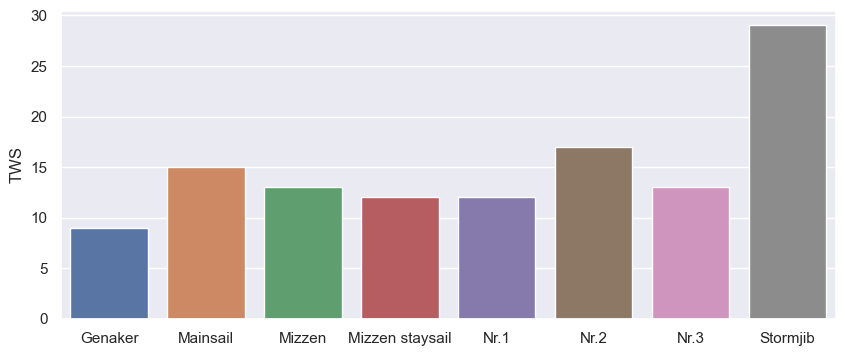

In [15]:
sns.set(rc={'figure.figsize':(10,4)})
sns.barplot(data=df_sail_usage, x=df_sail_usage.index, y='TWS')